In [9]:
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, QuantumRegister,ClassicalRegister, transpile

from IPython.display import Math
from qc_workbook.show_state import statevector_expr

print("----Start----")
simulator = AerSimulator(method='statevector')
print(simulator.name)

----Start----
aer_simulator_statevector


In [10]:
def oracle(circuit):
    circuit.x([0,2])
    circuit.mcx([0,1,2],3)
    circuit.x([0,2])

In [11]:
circuit = QuantumCircuit(4,3)

circuit.x(3)
circuit.h([0,1,2,3])

In [12]:
for _ in range(2):
    oracle(circuit)

    circuit.h([0,1,2])
    circuit.x([0,1,2])
    circuit.h(2)
    circuit.ccx(0,1,2)
    circuit.h(2)
    circuit.x([0,1,2])
    circuit.h([0,1,2])

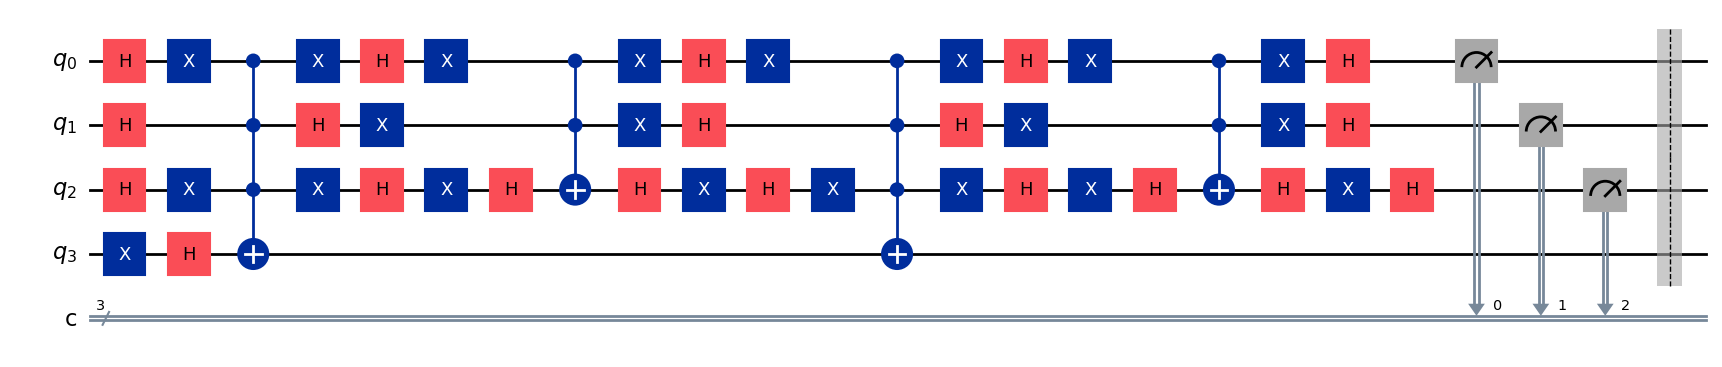

In [13]:
circuit.measure([0,1,2],[0,1,2])
circuit.barrier()
circuit.draw("mpl")

In [14]:
sim = AerSimulator()

compiled_circuit = transpile(circuit, sim, optimization_level=0)

job = sim.run(compiled_circuit, shots=1000) 
result = job.result()

counts = result.get_counts(compiled_circuit)
print(counts)

{'101': 6, '001': 6, '100': 4, '111': 7, '011': 12, '110': 10, '000': 12, '010': 943}
